# KNN algorithm

## Введение 
- Это небольшая лабораторная по реализации KNN алгоритма.

## Архитектура
- **test_train_split()** - Разбиение датасета на тренировочный и тестовый в случайном порядке с нужным количеством тестовых и тренировочных данных
- **KNeighborsClassifier** - Класс классификатора
    - **calculate_distance()** - Вычисление расстояния между точками (Манхэттенское расстояние)
    - **get_neighbors()** - Поиск всех соседей
    - **predict_classification()** - Классификация (Нахождение класса с максимальным числом вхождения в соседях)

## Требования:
- **Знание**:
    - **KNN algorithm**
    - **Функции нахождения расстояния** 
- **Библиотеки:** numpy, matplotlib, pandas, seaborn


## Выполнение

Импортируем необходимые библиотеки

In [130]:
import numpy as np

import pandas

import seaborn as sns
import matplotlib.pyplot as plt

Установим тему для отображения графиков

In [138]:
sns.set_theme(style="ticks")

Загрузим датасет (собственный или уже существующий). В качестве примера загрузим датасет с ирисами: [link](https://www.kaggle.com/datasets/uciml/iris/data)

- Отображение этого датасета - [link](https://www.kaggle.com/code/anantpandey29/complete-seaborn-guide-on-iris-dataset)

In [83]:
dataset_url = "https://raw.githubusercontent.com/plotly/datasets/refs/heads/master/iris-data.csv"

dataset = pandas.read_csv(dataset_url)

dataset.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Выведем зависимость между несколькими параметрами

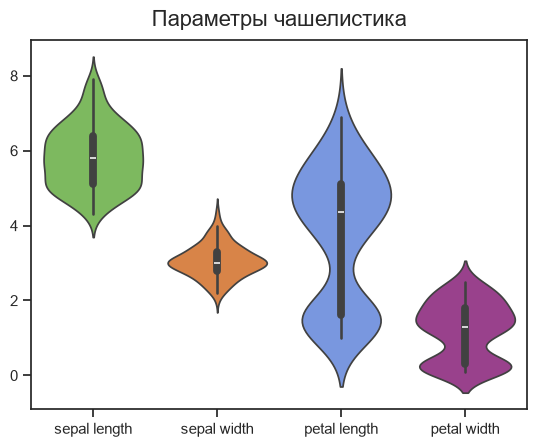

In [145]:
species_colors = ['#78C850',
                    '#F08030',
                    '#6890F0',
                    '#A83297'
                  ]

sns.violinplot(data=dataset, palette=species_colors)
#sns.scatterplot(data=dataset, x="sepal length", y="sepal width", hue="class", s=50, palette=species_colors)

plt.title("Параметры чашелистика", fontsize=16, pad=10)
#plt.xlabel("Длина чашелистика", fontsize=14)
#plt.ylabel("Ширина чашелистика", fontsize=14)
#plt.legend(title="Вид ириса", title_fontsize='13', loc='upper right')

plt.show()

Напишем функцию для разбиения всего датасета на тестовый и тренировочный

In [89]:
def test_train_split(dataset, train_number, test_number, seed=0):

    train_dataset = []
    test_dataset = []
    
    rng = np.random.default_rng(seed)

    rng.shuffle(dataset)

    for i in range(train_number):
        train_dataset.append(dataset[i])

    for i in range(train_number, train_number + test_number):
        test_dataset.append(dataset[i])

    return train_dataset, test_dataset
    

Создадим классификатор KNN

In [131]:
class KNeighborsClassifier:

    def __init__(self, K): # Инициализация параметров классификатора
        self.K = K

    def calculate_distance(self, current_point, main_point): # Манхэттенское расстояние
        distance = 0
        for i in range(len(main_point) - 1): # Исключаем название из подсчёта расстояния
            distance += np.absolute(current_point[i] - main_point[i])
        return distance

    def get_neighbors(self, points, main_point): # Получение всех соседей
        
        distances = []
        neighbors = []
        
        for current_point in points:
            distance = self.calculate_distance(current_point, main_point)
            distances.append((current_point, distance))
            
        distances.sort(key=lambda x: x[1]) # Сортируем по возрастанию дистанции

        for i in range(self.K):
            neighbors.append(distances[i][0])

        return neighbors

    def predict_classification(self, points, main_point): # Классификация на основе полученных соседей

        max_count = 0
        prediction = None
        
        neighbors = self.get_neighbors(points, main_point)
        neighbors_classes = set(neighbor[-1] for neighbor in neighbors)

        for neighbor_class in neighbors_classes:

            neighbor_class_count = 0
            
            for neighbor in neighbors:
                if neighbor[-1] == neighbor_class:
                    neighbor_class_count += 1
            
            if (max_count < neighbor_class_count):
                max_count = neighbor_class_count
                prediction = neighbor_class

        return prediction
        

Загразим датасет в массив

dataset_array = dataset.to_numpy()

Инициализируем классификатор, где **K** - количество соседей

In [146]:
KNNclassifier = KNeighborsClassifier(K = 2)

Создадим тренировочный и тестовый датасет из всего датасета (Их сумма должна равняться числу записей в датасете)

In [158]:
train_array, test_array = test_train_split(dataset_array, train_number = 50, test_number = 90)

Запустим классификацию на всех тренировочных данных и подсчитаем количество правильных и неправильных предсказаний

In [159]:
correct_predictions = 0
incorrect_predictions = 0

for point in test_array:
    prediction = KNNclassifier.predict_classification(train_array, point)

    if prediction == point[-1]:
        correct_predictions += 1
    else:
        incorrect_predictions +=1

print(f"Correct/Incorrect predictions: {correct_predictions} / {incorrect_predictions}")
print(f"Correct percentage: {((correct_predictions * 100)/ (correct_predictions + incorrect_predictions)):.2f}%")

Correct/Incorrect predictions: 85 / 5
Correct percentage: 94.44%
